## [Video RAG] VectorDB Indexing

In [5]:
%pip install -Uqqq langchain langchain-openai langchain-pinecone langchain-text-splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.6/587.6 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.3/259.3 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.6 MB/s eta 0:00:00


In [6]:
# 구글 드라이브 마운트 및 뎐동
from google.colab import drive # Colab에서 구글드라이브 사용 모듈
drive.mount('/content/drive') # 현재 런타임에서 내 구글드라이브 마운트 (연동)

BASE_PATH = '/content/drive/MyDrive/skn_34/05_multimodal_rag'

Mounted at /content/drive


In [7]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')
os.environ['PINECONE_API_KEY'] = userdata.get('PINECONE_API_KEY')

## 비디오별 caption 불러오기
- BASE_PATH/captions/{video_name}_frames.csv

In [8]:
captions_dir_path = os.path.join(BASE_PATH, 'captions') # captions 폴더 경로
# captions 폴더 내 파일들을 전체 경로 리스트로 변환
csv_files_path = [os.path.join(captions_dir_path, f) for f in os.listdir(captions_dir_path)]
csv_files_path

['/content/drive/MyDrive/skn_34/05_multimodal_rag/captions/alpinist_frames.csv',
 '/content/drive/MyDrive/skn_34/05_multimodal_rag/captions/basketball_frames.csv',
 '/content/drive/MyDrive/skn_34/05_multimodal_rag/captions/baseball_frames.csv',
 '/content/drive/MyDrive/skn_34/05_multimodal_rag/captions/skiing_frames.csv',
 '/content/drive/MyDrive/skn_34/05_multimodal_rag/captions/soccer_frames.csv']

In [10]:
# 여러 캡션 CSV로드 후 하나의 DataFrame으로 병합
import pandas as pd

dfs = [] # 각 CSV에서 읽은 DataFrame 리스트

for f in csv_files_path:
  df = pd.read_csv(f) # DataFrame 로드
  print(f"{os.path.basename(f)}: {df.shape = }")
  dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True) # 모든 DataFrame을 행 방향으로 합침 (인덱스 재부여)
print(all_df.shape)
all_df.head(20)

alpinist_frames.csv: df.shape = (23, 4)
basketball_frames.csv: df.shape = (14, 4)
baseball_frames.csv: df.shape = (25, 4)
skiing_frames.csv: df.shape = (12, 4)
soccer_frames.csv: df.shape = (12, 4)
(86, 4)


,id,video_filename,frame_no,description
0,abefa086-6764-44dd-8fd4-66ad3eb61caf,alpinist.mp4,0,주황색 재킷과 배낭을 착용한 등산객이 스틱을 짚으며 눈 덮인 산길을 오르고 있습니다...
1,88cc5a4c-5efc-4b4f-bc42-872fed64af29,alpinist.mp4,30,"등산객이 주황색 패딩과 배낭을 착용하고, 스틱과 아이젠을 이용해 눈 덮인 좁은 산길..."
2,59db71a4-7ef8-47b9-970a-a5143ba3d0bb,alpinist.mp4,60,"한 등산객이 주황색 패딩과 배낭을 착용하고, 양손에 등산 스틱을 든 채 눈 덮인 가..."
3,128c973a-ca0d-49d6-a53d-a0e924bb8681,alpinist.mp4,90,한 등산객이 주황색 재킷과 배낭을 착용하고 등산 스틱을 짚으며 눈 덮인 가파른 산길...
4,3ebd0b57-ff0e-43d4-a333-7dce8c5f484e,alpinist.mp4,120,"한 등산객이 주황색 재킷과 아이젠을 착용하고, 등산 스틱을 짚으며 눈 덮인 가파른 ..."
5,6ede0bea-af4c-45ef-9dec-6de722e4a438,alpinist.mp4,150,"등산객이 주황색 재킷과 아이젠을 착용하고, 스틱을 짚으며 눈 덮인 가파른 산길을 오..."
6,3c9f52e2-8e00-4088-a0bf-6bc4ed579636,alpinist.mp4,180,눈 덮인 험준한 산길에서 한 등산객이 스틱과 아이젠을 사용해 바위 절벽 옆을 오르고...
7,85abf133-b577-4a06-84b1-ae9463beb483,alpinist.mp4,210,눈 덮인 험준한 산길에서 한 등산객이 주황색 재킷과 스틱을 착용하고 바위와 눈 사이...
8,c0136bec-2f7b-46ae-8119-62d10f31e28e,alpinist.mp4,240,"한 등산객이 주황색 재킷과 배낭을 착용하고, 스틱을 짚으며 눈 덮인 가파른 암벽 산..."
9,129b4a1c-95fa-47c8-8283-0b1f1d09e47a,alpinist.mp4,270,"한 등산객이 주황색 재킷과 배낭을 착용하고, 스틱을 짚으며 눈 덮인 가파른 바위산을..."


## chunking

In [11]:
from langchain_text_splitters import RecursiveCharacterTextSplitter # Langchain 청크 분할기
from tqdm import tqdm
import uuid

# tiktoken 기준(모델 토큰화 방식)으로 분할기 객체 생성
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    model_name = 'gpt-5.6-luna', # 토큰 인코딩 기준 모델
    chunk_size = 300,            # 청크 목표 토큰 수
    chunk_overlap = 150,         # 청크 겹치는 토큰 수
    separators = ['\n\n','\n', ' ',''] # 분리 우선순위 (문단 -> 줄 -> 공백 -> 문자 단위)
)

In [12]:
# 프레임 캡션 텍스트를 청크로 분할해서 DataFrame 생성
chunks = [] # 분할된 청크들을 (dict) 형태로 누적할 리스트

for idx, row in tqdm(all_df.iterrows(), total=len(all_df)):
  frame_no = row['frame_no']
  video_filename = row['video_filename']
  description = row['description']

  # 여러 청크로 분할하여 청크단위로 순회
  for chunk in text_splitter.split_text(description):
    chunks.append({
        'id': str(uuid.uuid4()), # 고유 ID 생성
        'frame_no': frame_no,
        'video_filename': video_filename,
        'description': chunk
    })

chunks_df = pd.DataFrame(chunks)
print(chunks_df.shape) # 청크 데이터 (행, 열)
pd.set_option('display.max_colwidth', None) # df이 잘리지 않고 전체 보이도록 설정
chunks_df.head(10)

100%|██████████| 86/86 [00:00<00:00, 1837.90it/s]

(86, 4)


,id,frame_no,video_filename,description
0,99da98ca-a81d-4799-9a98-4eb34d308ae6,0,alpinist.mp4,"주황색 재킷과 배낭을 착용한 등산객이 스틱을 짚으며 눈 덮인 산길을 오르고 있습니다. 오른쪽에는 눈벽이 솟아 있고, 왼쪽으로는 가파른 암벽 능선과 먼 산악 풍경이 보입니다."
1,6cb46694-b20b-4ba9-8713-8fbd18a9c760,30,alpinist.mp4,"등산객이 주황색 패딩과 배낭을 착용하고, 스틱과 아이젠을 이용해 눈 덮인 좁은 산길을 오르고 있습니다. 오른쪽에는 높은 눈벽이, 왼쪽에는 가파른 바위 산비탈과 멀리 펼쳐진 풍경이 보입니다."
2,96c9207a-b891-444d-919c-6b892b6f25bb,60,alpinist.mp4,"한 등산객이 주황색 패딩과 배낭을 착용하고, 양손에 등산 스틱을 든 채 눈 덮인 가파른 산길을 오르고 있다. 오른쪽에는 높은 눈벽이 있고, 왼쪽으로는 바위산 능선과 넓은 풍경이 보인다."
3,73483eea-8a0b-49ab-a69c-e9c7a89e1bac,90,alpinist.mp4,"한 등산객이 주황색 재킷과 배낭을 착용하고 등산 스틱을 짚으며 눈 덮인 가파른 산길을 오르고 있습니다. 오른쪽에는 높은 설벽이, 왼쪽에는 바위산과 먼 산악 지형이 펼쳐져 있습니다."
4,31426633-24c9-431e-9cc3-df8690056d45,120,alpinist.mp4,"한 등산객이 주황색 재킷과 아이젠을 착용하고, 등산 스틱을 짚으며 눈 덮인 가파른 암벽 능선을 오르고 있습니다. 오른쪽에는 높은 눈벽이, 왼쪽 아래에는 험준한 산비탈과 광활한 풍경이 보입니다."
5,46dc8790-6011-4e85-a48f-58732d6aa226,150,alpinist.mp4,"등산객이 주황색 재킷과 아이젠을 착용하고, 스틱을 짚으며 눈 덮인 가파른 산길을 오르고 있다. 오른쪽에는 눈벽이, 왼쪽에는 암벽과 산 아래 풍경이 보인다."
6,51d3c465-6660-4d05-a374-87a16f29717c,180,alpinist.mp4,"눈 덮인 험준한 산길에서 한 등산객이 스틱과 아이젠을 사용해 바위 절벽 옆을 오르고 있다. 주변에는 가파른 설산과 암벽, 멀리 펼쳐진 산악 풍경이 보인다."
7,4bcb622e-0a1e-4914-98e1-f6e86cb78861,210,alpinist.mp4,"눈 덮인 험준한 산길에서 한 등산객이 주황색 재킷과 스틱을 착용하고 바위와 눈 사이를 오르고 있다. 오른쪽에는 높은 눈벽이, 왼쪽 아래에는 가파른 산비탈과 먼 풍경이 보인다."
8,d673f4b8-cda5-492c-b080-10b3b593861b,240,alpinist.mp4,"한 등산객이 주황색 재킷과 배낭을 착용하고, 스틱을 짚으며 눈 덮인 가파른 암벽 산길을 오르고 있다. 주변에는 두꺼운 눈과 바위가 이어지고, 왼쪽 아래로 산악 지형이 내려다보인다."
9,98a528c8-413c-400e-a64a-ffd63962c00f,270,alpinist.mp4,"한 등산객이 주황색 재킷과 배낭을 착용하고, 스틱을 짚으며 눈 덮인 가파른 바위산을 오르고 있다. 주변에는 두꺼운 설벽과 험준한 암벽이 펼쳐져 있다."


In [14]:
# 프레임(비디오+프레임번로)별 청크 개수 집계
chunks_df[['video_filename', 'frame_no']].value_counts().sort_index()

video_filename  frame_no
alpinist.mp4    0           1
                30          1
                60          1
                90          1
                120         1
                           ..
soccer.mp4      210         1
                240         1
                270         1
                300         1
                330         1
Name: count, Length: 86, dtype: int64

## indexing

In [16]:
from pinecone import Pinecone, ServerlessSpec

pc = Pinecone()
PINECONE_INDEX_NAME = 'video-caption-kr'
index_list = [index.name for index in pc.list_indexes()] # 현재 계정의 인덱스 이름 리스트

if PINECONE_INDEX_NAME not in index_list:
  pc.create_index(
      name = PINECONE_INDEX_NAME,
      dimension=1536,
      metric='cosine',
      # 클라우드 설정
      spec=ServerlessSpec(
          cloud='aws',
          region='us-east-1'
      )
  )
  print(f"{PINECONE_INDEX_NAME} 인덱스 생성 완료!")
else:
  print(f"{PINECONE_INDEX_NAME} 인덱스 이미 존재함!")

video-caption-kr 인덱스 생성 완료!


In [17]:
# OpenAI 임베딩 모델 결정 / 벡터스토어 연결
from langchain_openai import OpenAIEmbeddings # OpenAI 임베딩 생성기 (텍스트 -> 벡터)
from langchain_pinecone import PineconeVectorStore # Langchain에서 Pinecone 벡터스토어

embeddings = OpenAIEmbeddings(model='text-embedding-3-small') # 인덱스 dimension과 동일한 차원의 임베딩 모델

# 벡터스토어 구성
vector_store = PineconeVectorStore(
    index_name = PINECONE_INDEX_NAME,
    embedding = embeddings
)

In [23]:
texts = chunks_df['description'].tolist() # 청크 텍스트 description 리스트
metadatas = [
    {
        'id': row['id'],
        'frame_no': row['frame_no'],
        'video_filename': row['video_filename']
    }

      for idx , row in chunks_df.iterrows() # 데이터프레임 행별로 순회하면서
]

batch_size = 20

# 전체 텍스트를 baatch_size 단위로 반복 순회하면서
for i in tqdm(range(0, len(texts), batch_size)):
  batch_text = texts[i:i + batch_size]          # 현재 배치의 텍스트 슬라이싱
  batch_metadata = metadatas[i: i + batch_size] # 현재 배치의 메타데이터 슬라이싱
  vector_store.add_texts(batch_text, batch_metadata) # 텍스트 임베딩하여 Pinecone 업서트

100%|██████████| 5/5 [00:08<00:00,  1.62s/it]


In [24]:
query = '농구공으로 드리블하면서 상대방을 제치는 장면'

results = vector_store.similarity_search(query, k=3) # query 와 가장 유사한 청크 3개 벡터 검색
results

[Document(id='b88e39cf-1d17-4a0a-8e21-d3cfe2d9b07c', metadata={'frame_no': 270.0, 'id': '18965925-4df1-43f7-8621-498b1b37a4e0', 'video_filename': 'basketball.mp4'}, page_content='야외 농구장에서 검은 상의와 빨간 반바지를 입은 사람이 농구공을 드리블하고 있다. 뒤에는 농구 골대와 철제 펜스, 나무와 건물이 보이며, 오른쪽 가장자리에는 다른 사람의 일부가 함께 포착되어 있다.'),
 Document(id='2e0d7fcb-43fa-4ee9-991f-0bdd44f3030f', metadata={'frame_no': 60.0, 'id': '8eb9563d-702a-458f-9959-70c434d95999', 'video_filename': 'basketball.mp4'}, page_content='야외 농구장에서 여러 사람이 농구를 하고 있다. 붉은 머리띠를 한 선수가 공을 드리블하며 움직이고, 오른쪽에는 검은 유니폼을 입은 선수가 수비 자세를 취하고 있다. 뒤쪽에는 농구 골대와 철제 펜스, 나무와 건물이 보인다.'),
 Document(id='a8cd768e-e4e5-4b37-9362-4728a542d1a5', metadata={'frame_no': 90.0, 'id': 'eba3df7c-5ef6-4b05-9f2f-34fd9ec0df97', 'video_filename': 'basketball.mp4'}, page_content='야외 농구장에서 여러 사람이 농구 경기를 하고 있다. 중앙의 남성이 검은색 상의와 빨간 반바지를 입고 움직이고 있으며, 주변 선수들은 수비 자세를 취하고 있다. 뒤로 농구 골대와 철제 울타리, 나무가 보인다.')]

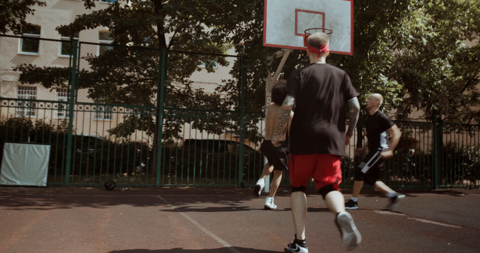

In [29]:
# 검색 결과 메타데이터로 원본 프레임 이미지 표시
from PIL import Image
import os

# 검색 결과 메타데이터를 기반으로 해장 프레임 이미지를 찾아 화면에 표시래주는 함수
def show_image_from_metadata(metadata, frame_dir='frames'):
  video_filename = metadata['video_filename']
  video_basename = os.path.splitext(video_filename)[0] # 확장자 제거
  frame_no = int(metadata['frame_no'])

  image_filename = f'{video_basename}_frame{frame_no:05d}.jpg' # 0 패딩 숫자 5자리 포함한 파일명
  image_patth = os.path.join(BASE_PATH, frame_dir, video_basename, image_filename) # 완성된 최종 경로

  image = Image.open(image_patth)
  image.thumbnail((480, 270))
  display(image)

show_image_from_metadata(results[0].metadata)

1
야외 농구장에서 검은 상의와 빨간 반바지를 입은 사람이 농구공을 드리블하고 있다. 뒤에는 농구 골대와 철제 펜스, 나무와 건물이 보이며, 오른쪽 가장자리에는 다른 사람의 일부가 함께 포착되어 있다.
{'frame_no': 270.0, 'id': '18965925-4df1-43f7-8621-498b1b37a4e0', 'video_filename': 'basketball.mp4'}


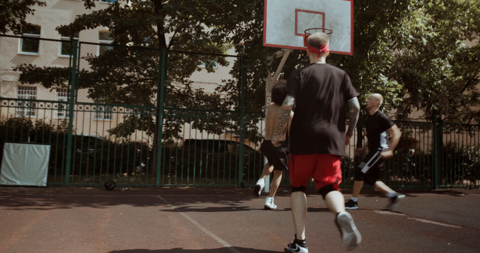

--------------------------------------------------
2
야외 농구장에서 여러 사람이 농구를 하고 있다. 붉은 머리띠를 한 선수가 공을 드리블하며 움직이고, 오른쪽에는 검은 유니폼을 입은 선수가 수비 자세를 취하고 있다. 뒤쪽에는 농구 골대와 철제 펜스, 나무와 건물이 보인다.
{'frame_no': 60.0, 'id': '8eb9563d-702a-458f-9959-70c434d95999', 'video_filename': 'basketball.mp4'}


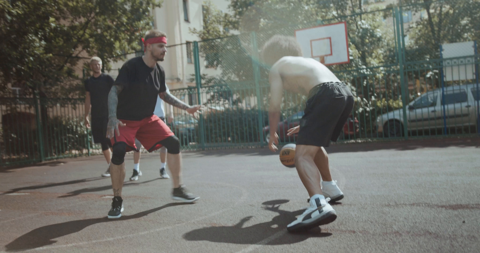

--------------------------------------------------
3
야외 농구장에서 여러 사람이 농구 경기를 하고 있다. 중앙의 남성이 검은색 상의와 빨간 반바지를 입고 움직이고 있으며, 주변 선수들은 수비 자세를 취하고 있다. 뒤로 농구 골대와 철제 울타리, 나무가 보인다.
{'frame_no': 90.0, 'id': 'eba3df7c-5ef6-4b05-9f2f-34fd9ec0df97', 'video_filename': 'basketball.mp4'}


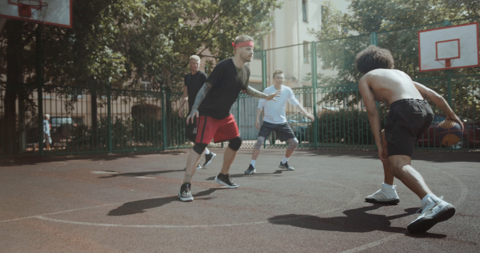

--------------------------------------------------


In [30]:
# 결과 모두 출력
for i, doc in enumerate(results):
  print(f'{(i + 1)}')
  print(doc.page_content) # 본문 텍스트
  print(doc.metadata)     # 문서 메타데이타
  show_image_from_metadata(doc.metadata) # 메타데이터 -> 이미지 표시
  print('-'*50)